## About Matrix Multiplications

### 1. Introduction

Matrix Multiplication (MatMul)

X @ W = Y

[M x K] @ [K x N] = [M, N]

Block matmul

### Basic dtypes

| Format | Bits | Exponent | Mantissa | Range | Precision |
|--------|------|----------|----------|-------|-----------|
| **FP32** | 32 | 8 | 23 | ~10³⁸ | ~7 decimal digits |
| **TensorFloat** | 19 | 8 | 10 | ~10³⁸ | ~7 decimal digits |
| **FP16** | 16 | 5 | 10 | ~10⁴ | ~3 decimal digits |
| **BF16** | 16 | 8 | 7 | ~10³⁸ | ~2 decimal digits |
| **FP8_E4M3** | 8 | 4 | 3 | ~10³⁸ | ~2 decimal digits |

FP32

FP16, gradient scaling

BF16

torch.set_matmul_precision

TensorFloat

### Advanced

INT8, group scaling

FLOAT8, e5m2, e4m3, e3m4

MXFP4, NVFP4

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
import triton

DEVICE = triton.runtime.driver.active.get_active_torch_device()

from matmul_fp8_fp8 import matmul_fp8_fp8
from linear_with_fp8_cast import matmul_autocast_fp8

In [3]:
def prepare_args_fp32_fp32(M, N, K):
    X = torch.randn(M, K, dtype=torch.float32).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.float32).to(DEVICE) / K ** 0.5
    return X, W

def prepare_args_fp16_fp16(M, N, K):
    X = torch.randn(M, K, dtype=torch.float16).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.float16).to(DEVICE) / K ** 0.5
    return X, W

def prepare_args_bf16_bf16(M, N, K):
    X = torch.randn(M, K, dtype=torch.bfloat16).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.bfloat16).to(DEVICE) / K ** 0.5
    return X, W

def prepare_args_fp8_fp8(M, N, K):
    X = torch.randn(M, K, dtype=torch.bfloat16).to(torch.float8_e4m3fn).to(DEVICE)
    W = (torch.randn(K, N, dtype=torch.bfloat16)  / K ** 0.5).to(torch.float8_e4m3fn).to(DEVICE)
    return X, W

In [4]:
@torch.no_grad()
def benchmark_matmul(M, N, K, prepare_args_fn, matmul_fn, quantiles=[0.5, 0.1, 0.9]):
    args = prepare_args_fn(M, N, K)
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: matmul_fn(*args), quantiles=quantiles)
    perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)

## Compare computation speed

matmul-performance:
         K        M        N  fp32@fp32 (TFLOPS)  fp16@fp16 (TFLOPS)  bf16@bf16 (TFLOPS)  fp8@fp8 (TFLOPS)
0   4096.0   4096.0   4096.0           30.739267           86.441332           80.898217        171.695673
1   8192.0   8192.0   8192.0           30.882605           88.417250           89.766719        156.597751
2  16384.0  16384.0  16384.0           30.694892           88.872122          100.936930        160.475628


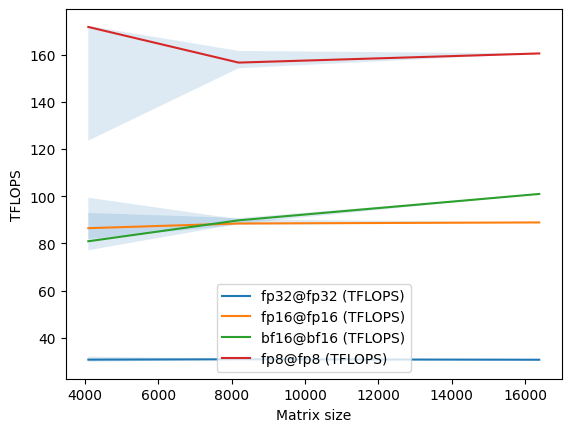

In [ ]:
test_shapes = [
    [4096, 4096, 4096],
    [8192, 8192, 8192],
    [16384, 16384, 16384],
    ]

experiments = [
            "fp32@fp32",
            "fp16@fp16",
            "bf16@bf16",
            "fp8@fp8",
            ]

configs = []
configs.append(
    triton.testing.Benchmark(
        x_names=["K", "M", "N"],
        x_vals=[shape for shape in test_shapes],
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        line_vals=experiments,
        line_names=experiments,
        ylabel="TFLOPS",  # Label name for the y-axis
        xlabel="Matrix size",
        plot_name="matmul-performance",  # Name for the plot, used also as a file name for saving the plot.
        args={},
    ))

@triton.testing.perf_report(configs)
def benchmark(M, K, N, provider):

    if provider == "fp32@fp32":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp32_fp32,
            matmul_fn=torch.matmul
        )
    if provider == "fp16@fp16":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp16_fp16,
            matmul_fn=torch.matmul
        )
    if provider == "bf16@bf16":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_bf16_bf16,
            matmul_fn=torch.matmul
        )
    if provider == "fp8@fp8":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp8_fp8,
            matmul_fn=matmul_fp8_fp8
        )
    return perf

About autocast



## Take into account base type

matmul-performance:
         K        M        N  fp32@fp32 (TFLOPS)  fp32@fp32_set_fp32_prec (TFLOPS)  fp32@fp32_cast_bf16 (TFLOPS)  bf16@bf16 (TFLOPS)  bf16@bf16_fp8_kernel (TFLOPS)  fp8@fp8 (TFLOPS)
0   4096.0   4096.0   4096.0           30.849331                         42.343525                     68.231484           80.356365                     116.812648        172.139531
1   8192.0   8192.0   8192.0           30.641131                         44.256114                     82.154143           90.690644                     135.787782        158.674703
2  16384.0  16384.0  16384.0           30.706851                         44.949710                     86.788055           93.374374                     142.328213        159.176037


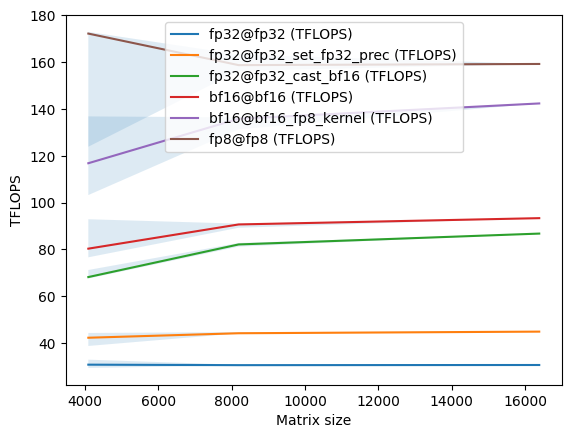

In [ ]:
test_shapes = [
    [4096, 4096, 4096],
    [8192, 8192, 8192],
    [16384, 16384, 16384],
    ]

experiments = [
            "fp32@fp32",
            "fp32@fp32_set_fp32_prec",
            "fp32@fp32_cast_bf16",
            "bf16@bf16",
            "bf16@bf16_fp8_kernel",
            "fp8@fp8",
            ]

configs = []
configs.append(
    triton.testing.Benchmark(
        x_names=["K", "M", "N"],
        x_vals=[shape for shape in test_shapes],
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        line_vals=experiments,
        line_names=experiments,
        ylabel="TFLOPS",  # Label name for the y-axis
        xlabel="Matrix size",
        plot_name="matmul-performance",  # Name for the plot, used also as a file name for saving the plot.
        args={},
    ))

@triton.testing.perf_report(configs)
def benchmark(M, K, N, provider):
    if provider == "fp32@fp32":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp32_fp32,
            matmul_fn=torch.matmul
        )
    if provider == "fp32@fp32_set_fp32_prec":
        """
        https://docs.pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html
        """
        torch.set_float32_matmul_precision("high")
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp32_fp32,
            matmul_fn=torch.matmul
        )
        torch.set_float32_matmul_precision("highest")
    if provider == "fp32@fp32_cast_bf16":
        """
        https://docs.pytorch.org/docs/stable/amp.html
        """
        with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
            perf = benchmark_matmul(
                M=M, N=N, K=K,
                prepare_args_fn=prepare_args_fp32_fp32,
                matmul_fn=torch.matmul
            )
    if provider == "bf16@bf16":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_bf16_bf16,
            matmul_fn=torch.matmul
        )
    if provider == "fp32@fp32_autocast_bf16":
        with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
            perf = benchmark_matmul(
                M=M, N=N, K=K,
                prepare_args_fn=prepare_args_fp32_fp32,
                matmul_fn=torch.matmul
            )
    if provider == "bf16@bf16_fp8_kernel":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_bf16_bf16,
            matmul_fn=matmul_autocast_fp8
        )
    if provider == "fp8@fp8":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp8_fp8,
            matmul_fn=matmul_fp8_fp8
        )
    return perf

## Linear: Forward + Backward

X - 

L(X, W) - loss functio